In [ ]:
import pandas as pd
from google.cloud import speech
import numpy as np
import matplotlib.pyplot as plt
from jiwer import wer
import seaborn as sns
import shutil
import os

## Introduction
#### Data: Meta AI Fair Speech Dataset -- An open-source audio dataset of 26,471 utterances from 593 people in the US who were paid to record and submit audio of themselves saying commands in response to prompts that relate to music, capture, utilities, notification control, messaging, calling, and dictation. For example, 'How would you search for a song?' This dataset was designed with speech recognition for digital assistants in mind as its intended application. I randomly sampled 100 utterances for each of my three groups of interest.
#### API -- Google's Chirp 3 API -- An open-source multilinguial speech model that is marketed for transcription and speech synthesis applications.
#### Hypothesis -- The speech-to-text model will have a higher word error rate for English as a Second Language speakers whose first language is underrepresented in the dataset compared to English, particularly Hindi and Urdu.
#### Motivation -- Speech-to-text systems should work for a variety of users in order to be effective and fair applications, including individuals whose first language was not English and may speak with an accent, but it's unclear what the makeup of the training datasets are that power these high profile models. I'd like to test how accurate a common open-source speech-to-text model is for individuals whose first language is highly represented in the global population but not US demographics, such as Hindi (865k speakers in the US vs. 600m worldwide) and Urdu (508k speakers in the US vs. 230m worldwide). Additionally, I'm interested in how a model trained by one large tech company will perform on a dataset from a different company, in this case Google and Meta, respectively.

##### Sample audio files for each subgroup

In [ ]:
raw_data = pd.read_csv("asr_fairness_audio/metadata.tsv", sep='\t')

n_samples = 100
langs = ["English","Hindi","Urdu"]

filename_dict = {l:[] for l in langs}
for l in langs:
    lang_subset = raw_data[raw_data["first_language"]==l]

    # random sample of files
    rand_samp = lang_subset.sample(n_samples)
    files = rand_samp["hash_name"].tolist()
    filename_dict[l] = files

    # save file name and transcription
    rand_samp.to_csv(f"audio_subset/{l}/{l}_metadata.csv")

    # copy files over
    for file in files:
        shutil.copy(f"asr_fairness_audio/{file}.wav", f"audio_subset/{l}/")

# combine subsets together for subset eda
eng_df = pd.read_csv("audio_subset/English/English_metadata.csv").drop(columns=["Unnamed: 0"],inplace=False)
hindi_df = pd.read_csv("audio_subset/Hindi/Hindi_metadata.csv").drop(columns=["Unnamed: 0"],inplace=False)
urdu_df = pd.read_csv("audio_subset/Urdu/Urdu_metadata.csv").drop(columns=["Unnamed: 0"],inplace=False)

sub_df = pd.concat([eng_df, hindi_df, urdu_df], ignore_index=True)
sub_df.to_csv("audio_subset/subset_metadata.csv",index=False)

#### Call API to transcribe speech

In [ ]:
def transcribe(filepaths:list):
    # Instantiates a client
    client = speech.SpeechClient()

    # The name of the local audio filepath
    gcs_uri = "gs://asr_fairness_audio_data/"

    # model config
    config = speech.RecognitionConfig(
        encoding=speech.RecognitionConfig.AudioEncoding.LINEAR16,
        sample_rate_hertz=16000,
        language_code="en-US",
    )

    # store output
    outs = []

    print("Transcribing...")
    for f in filepaths:
        # transcription
        audio = speech.RecognitionAudio(uri=gcs_uri+f)
        response = client.recognize(config=config, audio=audio)

        # concatenate transcriptions and add to output
        curr_out = ""
        for result in response.results:
            curr_out += result.alternatives[0].transcript
        outs.append(curr_out)

    print("Done!")
    return outs

In [ ]:
# get input files and metadata
metadata = pd.read_csv("audio_subset/subset_metadata.csv")
trans_true = metadata["transcription"].tolist()

# filenames for passing to func
filenames = [f"{f}.wav" for f in metadata["hash_name"].tolist()]

# generate transcriptions
trans_preds = transcribe(filenames)

Transcribing...
Done!


In [17]:
# save outputs
model_output = metadata.copy()
model_output["model_transcription"] = trans_preds
model_output.to_csv("audio_subset/full_data.csv",index=False)

#### Analyze results

In [3]:
# load results
results = pd.read_csv("audio_subset/full_data.csv")
results.head()

,hash_name,transcription,age,gender,first_language,socioeconomic_bkgd,ethnicity,audio_dur,model_transcription
0,b473df3459cbdb3a6f52aeb8fc4ffa04,hey facebook share the video to my father,23 - 30,female,English,Low,"Asian, South Asian or Asian American",NaN,hey Facebook shared a video to my father
1,9354446bd6fd89b0d21fbf40d9207514,hi dear i am very much frustrated about these ...,31 - 45,female,Urdu,Low,"Asian, South Asian or Asian American",40.426313,hi there I am very much frustrated about these...
2,646476ccb1600967617ac069225bd38d,hi love i was just talking to my friend and we...,31 - 45,female,Hindi,Affluent,"Asian, South Asian or Asian American",33.407625,hi love I was just um talking to my friend and...
3,54f999c8833022f986e79c51a085592f,reply back to george the second saying hey ran...,31 - 45,male,English,Low,"Hispanic, Latino, or Spanish",29.247625,reply back to George II saying hey random fact...
4,1485f39500388c731f2f432884e7e6db,hi you just called me and i was really shocked...,31 - 45,female,Urdu,Low,"Asian, South Asian or Asian American",28.821000,hi uh you just called me and I was really shoc...


##### Ground Truth Transcriptions

In [56]:
# ground truths 
for t in results["transcription"].tolist():
    print(t)

hey facebook share the video to my father
hi dear i am very much frustrated about these screens and like i am having like bugs problem in my house but it is not getting done like soon and my kids also having trouble with this so please get it done as soon as possible thank you and the other way is i am really frustrated how slow your maintenance procedure is i am sending through email messages and all and i am not getting any solution for it thank you
hi love i was just talking to my friend and we were just discussing random things and she just mentioned the fact that it is impossible for most people to touch their elbows with their tongue and i found it so funny let's try it with the kids tonight and see if any of us can touch our elbows with our tongue bye
reply back to george the second saying hey random fact there is no way that baby whales consume two hundred liters of milk a day finish text message send
hi you just called me and i was really shocked that you lost your pet yesterd

##### Experimental Transcriptions

In [ ]:
# experimental transcriptions
for t in results["model_transcription"].tolist():
    print(t)

hey Facebook shared a video to my father
hi there I am very much frustrated about these screens and like uh I am having like bugs problem in my house but it is not getting done like soon and my kids also having trouble with this so please get it done as soon as possible thank you and the other way is I am really frustrated how slow your maintenance procedure is I am sending you email messages and all and I am not getting any solution for it thank you
hi love I was just um talking to my friend and uh we were just discussing random things and she just mentioned the fact that it is impossible for most people to touch their elbows with their tongue um and I found it so funny let's try it with the kids tonight and see if any of us can touch our elbows with our tongue by
reply back to George II saying hey random fact there is no way that baby whales consume 200 liters of milk a day finish text message send
hi uh you just called me and I was really shocked that you lost your pet yesterday and

In [ ]:
# calculate word error rate
results["WER"] = [wer(row.transcription, row.model_transcription) for idx,row in results.iterrows()]

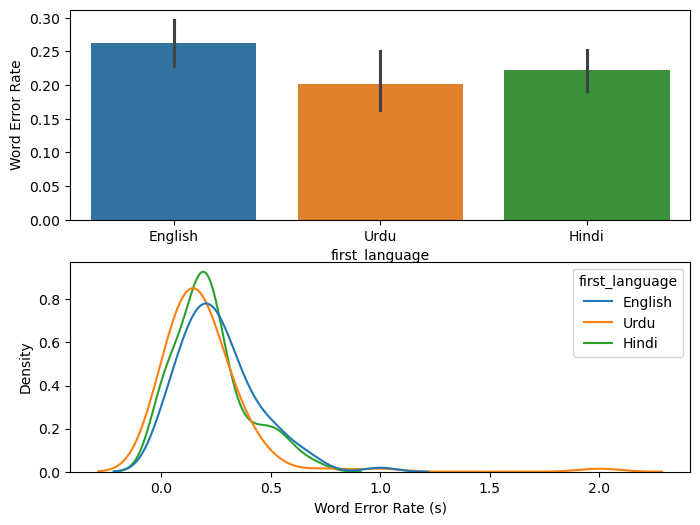

In [71]:
fig,axes = plt.subplots(2,1,figsize=(8,6))
sns.barplot(data=results, y="WER", x="first_language", hue="first_language",ax=axes[0])
axes[0].set_ylabel("Word Error Rate")
sns.kdeplot(data=results, x="WER", hue="first_language", ax=axes[1])
axes[1].set_xlabel("Word Error Rate (s)")
plt.show()

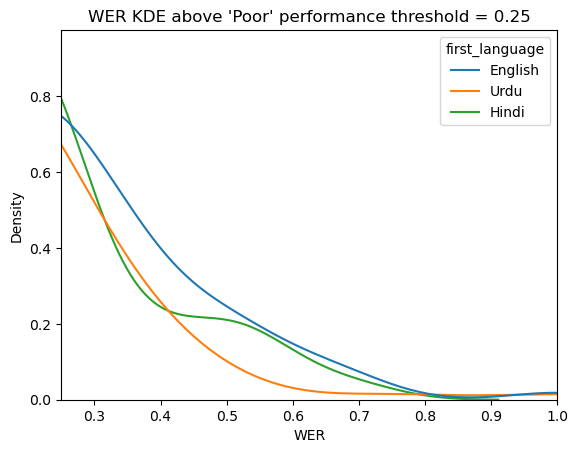

In [72]:
plt.figure()
sns.kdeplot(data=results,x="WER",hue="first_language")
plt.xlim([0.25,1.0])
plt.title("WER KDE above 'Poor' performance threshold = 0.25")
plt.show()

In [48]:
wer_meds = results.groupby(by="first_language",as_index=False).median("WER").drop(columns=["audio_dur"],inplace=False)
wer_meds

,first_language,WER
0,English,0.250000
1,Hindi,0.200000
2,Urdu,0.156732


In [59]:
eng_std = results[results["first_language"]=="English"]["WER"].std()
hindi_std = results[results["first_language"]=="Hindi"]["WER"].std()
urdu_std = results[results["first_language"]=="Urdu"]["WER"].std()

print(f"English StdDev: {np.round(eng_std,4)}")
print(f"Hindi StdDev: {np.round(hindi_std,4)}")
print(f"Urdu StdDev: {np.round(urdu_std,4)}")

English StdDev: 0.1815
Hindi StdDev: 0.1643
Urdu StdDev: 0.2393


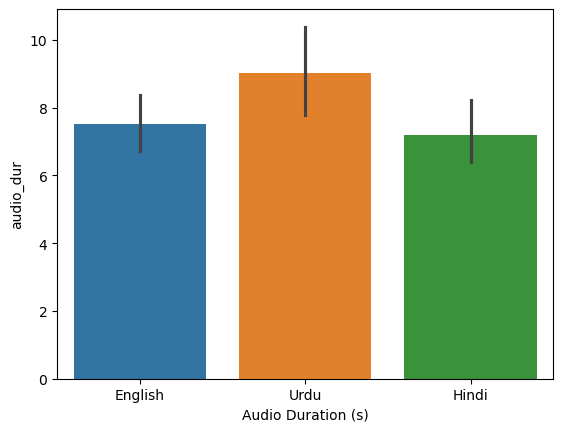

In [29]:
plt.figure()
sns.barplot(data=results, y="audio_dur", x="first_language", hue="first_language")
plt.xlabel("Audio Duration (s)")
plt.show()

In [49]:
wer_meds = results.groupby(by="first_language",as_index=False).median("audio_dur").drop(columns=["WER"],inplace=False)
wer_meds

,first_language,audio_dur
0,English,5.887625
1,Hindi,5.542500
2,Urdu,6.922313


In [60]:
eng_std = results[results["first_language"]=="English"]["audio_dur"].std()
hindi_std = results[results["first_language"]=="Hindi"]["audio_dur"].std()
urdu_std = results[results["first_language"]=="Urdu"]["audio_dur"].std()

print(f"English StdDev: {np.round(eng_std,4)}")
print(f"Hindi StdDev: {np.round(hindi_std,4)}")
print(f"Urdu StdDev: {np.round(urdu_std,4)}")

English StdDev: 4.4015
Hindi StdDev: 4.6615
Urdu StdDev: 6.3128


#### Discussion
##### I observed lower median Word Error Rater (WER) for both of the less represented first-language groups - Hindi and Urdu - compared to the dominant first language English. English had a median WER of 0.25 (std dev = 0.18), Hindi had a median WER of 0.2 (std dev = 0.16), and Urdu had a median WER of 0.1567 (std dev = 0.24). Next, I wanted to see whether the aggregate statistical measure of median was masking any meaningful differences in the underlying distribution of WER across groups beyond the threshold for 'poor' speech-to-text performance of 0.25 WER. Both Urdu and Hindi have fewer transcriptions beyond this 'poor performance' threshold, which indicates that for this small sample size that their performance is not qualitatively worse than English.  So my original hypothesis that these less represented first-language demographics would have worse performance is false, at least under qualitative observation. I also wanted to see if maybe there was an underlying difference in audio duration that may be skewing the WER metric, as it could have been the case that one subgroup had meaningfully longer or shorter audio clips, but found that the median and standard deviation of audio duration was about the same for all groups. It's possible that because many of these audio clips are clearly stated verbal commands to a smart-home assistant or speech directed at someone through their phone, this API may perform differently during in-person conversational speech due to potentially different acoustic or phonetic properties. Overall though, it seems that the Google Cloud Speech-to-Text API does not perform qualitatively worse for less-represented groups whose first language is not English, in particular Hindi and Urdu. 

#### Citations
- Meta AI Fair Speech Dataset. https://ai.meta.com/datasets/speech-fairness-dataset/
- Google Cloud Speech to Text. https://docs.cloud.google.com/speech-to-text/docs/overview#:~:text=for%20feature%20availability.-,Model%20selection,select%20one%20in%20your%20requests.
- Languages of the US. https://en.wikipedia.org/wiki/Languages_of_the_United_States
- 10 most spoken languages in the world in 2025. https://www.icls.edu/blog/most-spoken-languages-in-the-world
- Improving fairness and robustness in speech recognition. https://ai.meta.com/blog/improving-fairness-and-robustness-in-speech-recognition/
- code for API call modified from tutorial for Google Cloud's Speech-to-Text
- What is word error rate? https://www.llamaindex.ai/glossary/what-is-word-error-rate
- How Google AI's Chirp3 HD is Quietly Changing AI Interaction. https://medium.com/@aitechtoolbox48/how-googles-chirp-3-hd-is-quietly-changing-ai-interaction-f63ca9cd6211